In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# FIND PROJECT ROOT
# =========================================================

PROJECT_ROOT = Path.cwd().resolve()

# If the notebook is running from the notebooks folder,
# move one level up to the project root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


# =========================================================
# DATA PATH
# =========================================================

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cleaned_survey.csv"
)


# =========================================================
# CHECK DATASET
# =========================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found at:\n{DATA_PATH}"
    )


# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv(DATA_PATH)


# =========================================================
# BASIC INFORMATION
# =========================================================

print("=" * 70)
print("OUTLOOK CUSTOMER INTELLIGENCE")
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)

print(
    f"\nDataset shape: "
    f"{df.shape[0]:,} rows × {df.shape[1]:,} columns"
)

print(
    f"\nDataset location:\n{DATA_PATH}"
)

OUTLOOK CUSTOMER INTELLIGENCE
EXPLORATORY DATA ANALYSIS

Dataset shape: 11,109 rows × 101 columns

Dataset location:
C:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\data\processed\cleaned_survey.csv


In [2]:
df.head()


,age_group,gender,education_level,residence_type,employment_status,which_is_your_preferred_medium_of_keeping_yourself_updated,do_you_prefer_print_magazines_or_digital_magazines,do_you_read_magazines,outlook_awareness_1,when_you_think_of_indian_magazine_brand_which_is_the_one_that_first_pops_up_in_your_mind,...,which_amongst_the_following_is_the_brand_personality_of_outlook,awareness_consistent,awareness_disagreement,recommendation_category,repurchase_intent_score,rating_mean,rating_std,rating_range,rating_unique_count,potential_low_variation_response
0,18-35,Male,Graduation,Urban Area,Self Employed,Television,Digital,Yes,Yes,Forbes,...,Excitement,False,1,Promoter,3,3.583333,1.443376,4,4,False
1,35-50,Male,Post graduation,Urban Area,Unemployed,Digitally,Print,No,No,GQ,...,Trendy Smart,True,0,Promoter,3,2.916667,1.564279,4,4,False
2,35-50,Female,Graduation,Urban Area,Unemployed,Digitally,Digital,Sometimes,No,Vogue,...,Business Minded,True,0,Promoter,3,3.583333,1.164500,4,5,False
3,18-35,Female,School,Rural Area,Student,Digitally,Print,No,No,GQ,...,Gentle,True,0,Promoter,2,2.916667,1.311372,4,5,False
4,18-35,Female,Post graduation,Rural Area,Employed,Digitally,Digital,No,Yes,Femina,...,Trendy Smart,False,1,Passive,1,3.083333,1.378954,4,5,False


In [3]:
df.shape

(11109, 101)

In [4]:
important_columns = [
    "age_group",
    "gender",
    "education_level",
    "employment_status",
    "outlook_awareness_1",
    "outlook_awareness_2",
    "outlook_familiarity",
    "recommendation",
    "recommendation_category",
    "previous_purchase",
    "repurchase_intent",
    "repurchase_intent_score",
    "service_rating",
    "content_rating",
    "price_rating",
    "delivery_rating",
    "previous_experience_rating",
    "customer_support_rating",
]

available_columns = [
    column
    for column in important_columns
    if column in df.columns
]

missing_columns = [
    column
    for column in important_columns
    if column not in df.columns
]

print("IMPORTANT VARIABLES FOUND:")
for column in available_columns:
    print(f"✓ {column}")

print("\nIMPORTANT VARIABLES NOT FOUND:")
for column in missing_columns:
    print(f"✗ {column}")

IMPORTANT VARIABLES FOUND:
✓ age_group
✓ gender
✓ education_level
✓ employment_status
✓ outlook_awareness_1
✓ outlook_awareness_2
✓ outlook_familiarity
✓ recommendation
✓ recommendation_category
✓ previous_purchase
✓ repurchase_intent
✓ repurchase_intent_score
✓ service_rating
✓ content_rating
✓ price_rating
✓ delivery_rating
✓ previous_experience_rating
✓ customer_support_rating

IMPORTANT VARIABLES NOT FOUND:


In [5]:
df.head()

,age_group,gender,education_level,residence_type,employment_status,which_is_your_preferred_medium_of_keeping_yourself_updated,do_you_prefer_print_magazines_or_digital_magazines,do_you_read_magazines,outlook_awareness_1,when_you_think_of_indian_magazine_brand_which_is_the_one_that_first_pops_up_in_your_mind,...,which_amongst_the_following_is_the_brand_personality_of_outlook,awareness_consistent,awareness_disagreement,recommendation_category,repurchase_intent_score,rating_mean,rating_std,rating_range,rating_unique_count,potential_low_variation_response
0,18-35,Male,Graduation,Urban Area,Self Employed,Television,Digital,Yes,Yes,Forbes,...,Excitement,False,1,Promoter,3,3.583333,1.443376,4,4,False
1,35-50,Male,Post graduation,Urban Area,Unemployed,Digitally,Print,No,No,GQ,...,Trendy Smart,True,0,Promoter,3,2.916667,1.564279,4,4,False
2,35-50,Female,Graduation,Urban Area,Unemployed,Digitally,Digital,Sometimes,No,Vogue,...,Business Minded,True,0,Promoter,3,3.583333,1.164500,4,5,False
3,18-35,Female,School,Rural Area,Student,Digitally,Print,No,No,GQ,...,Gentle,True,0,Promoter,2,2.916667,1.311372,4,5,False
4,18-35,Female,Post graduation,Rural Area,Employed,Digitally,Digital,No,Yes,Femina,...,Trendy Smart,False,1,Passive,1,3.083333,1.378954,4,5,False


In [6]:
df.shape

(11109, 101)

In [7]:
# =========================================================
# CUSTOMER PROFILE
# =========================================================

demographic_columns = [
    "age_group",
    "gender",
    "education_level",
    "residence_type",
    "employment_status"
]

for column in demographic_columns:

    print("\n" + "=" * 70)
    print(column.upper())
    print("=" * 70)

    summary = (
        df[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="count")
    )

    summary["percentage"] = (
        summary["count"]
        / len(df)
        * 100
    ).round(2)

    print(summary.to_string(index=False))


AGE_GROUP
   age_group  count  percentage
       35-50   2849       25.65
Less than 18   2848       25.64
         70+   2750       24.75
       18-35   2662       23.96

GENDER
gender  count  percentage
Female   5575       50.18
  Male   5534       49.82

EDUCATION_LEVEL
education_level  count  percentage
Post graduation   2870       25.83
            PhD   2810       25.29
         School   2753       24.78
     Graduation   2676       24.09

RESIDENCE_TYPE
residence_type  count  percentage
    Rural Area   5611       50.51
    Urban Area   5498       49.49

EMPLOYMENT_STATUS
employment_status  count  percentage
    Self Employed   2818       25.37
         Employed   2777       25.00
       Unemployed   2770       24.93
          Student   2744       24.70


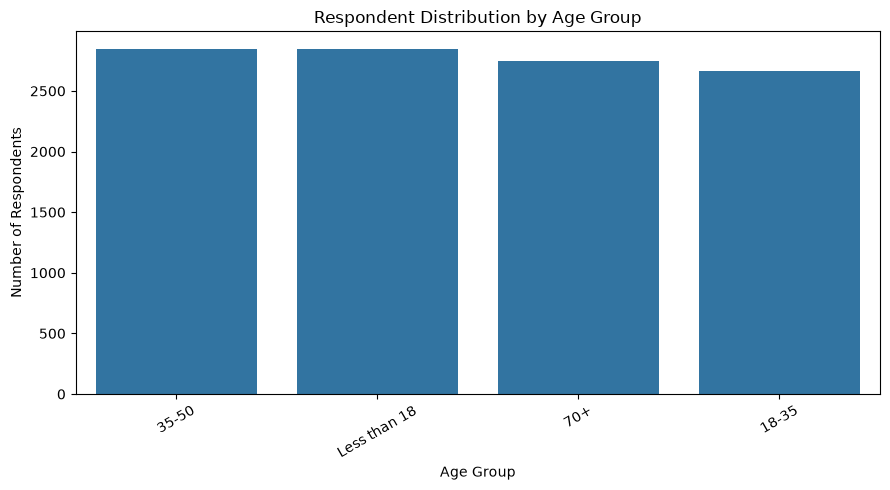

In [8]:
# =========================================================
# AGE DISTRIBUTION
# =========================================================

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="age_group",
    order=df["age_group"].value_counts().index
)

plt.title("Respondent Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Respondents")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

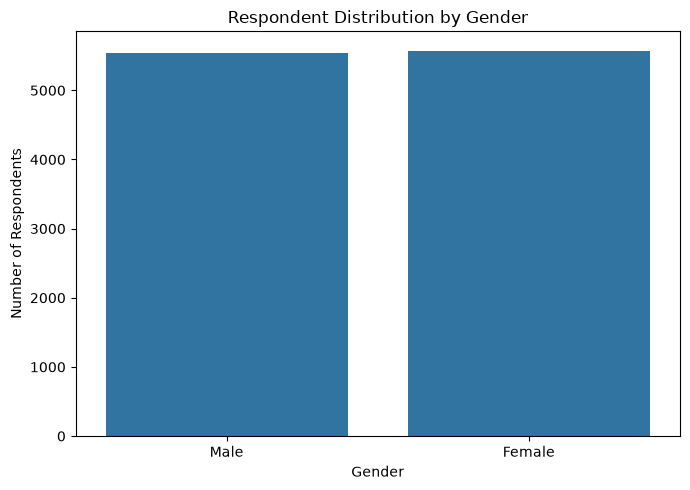

In [9]:
# =========================================================
# GENDER DISTRIBUTION
# =========================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Respondent Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.show()

In [10]:
# =========================================================
# BRAND AWARENESS KPI
# =========================================================

awareness_counts = (
    df["outlook_awareness_1"]
    .value_counts()
)

awareness_percentage = (
    df["outlook_awareness_1"]
    .value_counts(normalize=True)
    * 100
)

awareness_summary = pd.DataFrame({
    "count": awareness_counts,
    "percentage": awareness_percentage.round(2)
})

awareness_summary

,count,percentage
outlook_awareness_1,,
No,5623,50.62
Yes,5486,49.38


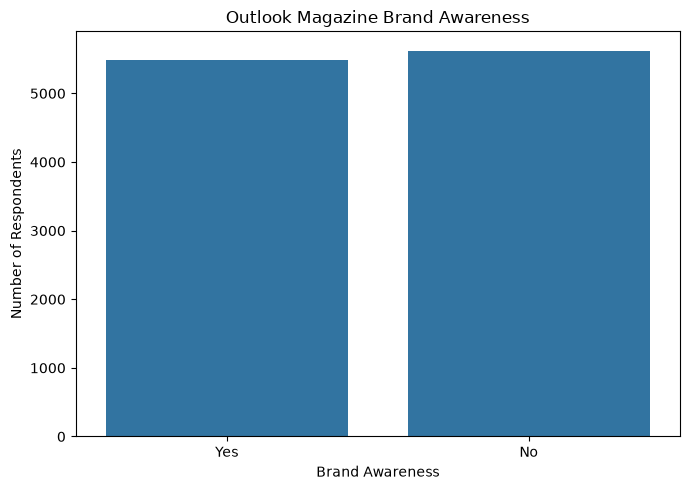

In [11]:
# =========================================================
# BRAND AWARENESS VISUALIZATION
# =========================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="outlook_awareness_1"
)

plt.title("Outlook Magazine Brand Awareness")
plt.xlabel("Brand Awareness")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.show()

In [12]:
# =========================================================
# AWARENESS BY AGE GROUP
# =========================================================

awareness_age = pd.crosstab(
    df["age_group"],
    df["outlook_awareness_1"],
    normalize="index"
) * 100

awareness_age.round(2)

outlook_awareness_1,No,Yes
age_group,,
18-35,49.89,50.11
35-50,50.79,49.21
70+,51.42,48.58
Less than 18,50.35,49.65


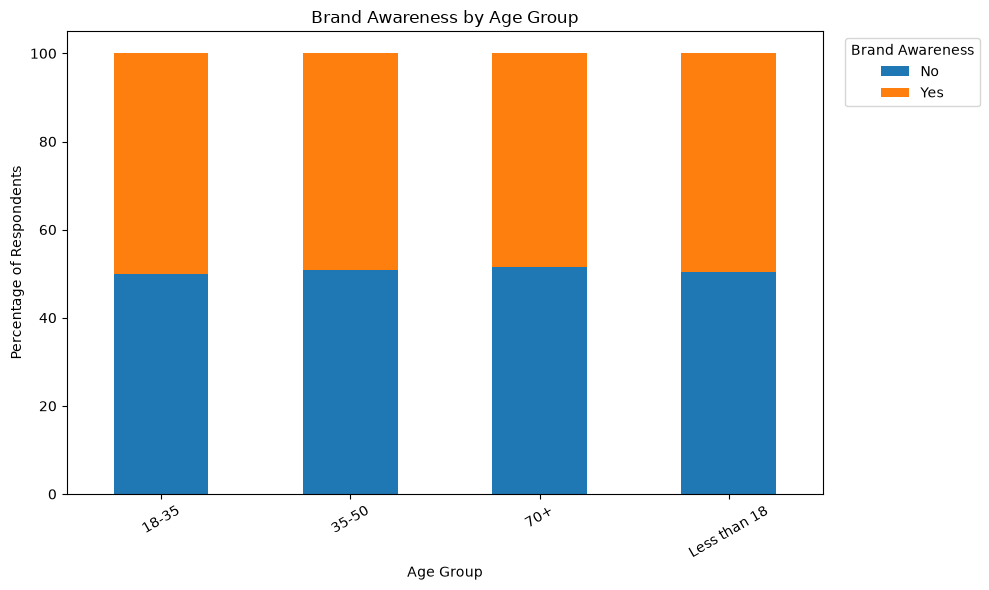

In [13]:
# =========================================================
# AWARENESS BY AGE — STACKED BAR
# =========================================================

awareness_age.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Brand Awareness by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage of Respondents")

plt.legend(
    title="Brand Awareness",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [14]:
# =========================================================
# BRAND DISCOVERY CHANNEL
# =========================================================

discovery_summary = (
    df["brand_discovery_method"]
    .value_counts()
    .rename_axis("discovery_method")
    .reset_index(name="count")
)

discovery_summary["percentage"] = (
    discovery_summary["count"]
    / len(df)
    * 100
).round(2)

discovery_summary

,discovery_method,count,percentage
0,I myself read it,2286,20.58
1,People who I know read it,2243,20.19
2,Social Media,2222,20.00
3,Print Media,2182,19.64
4,Others,2176,19.59


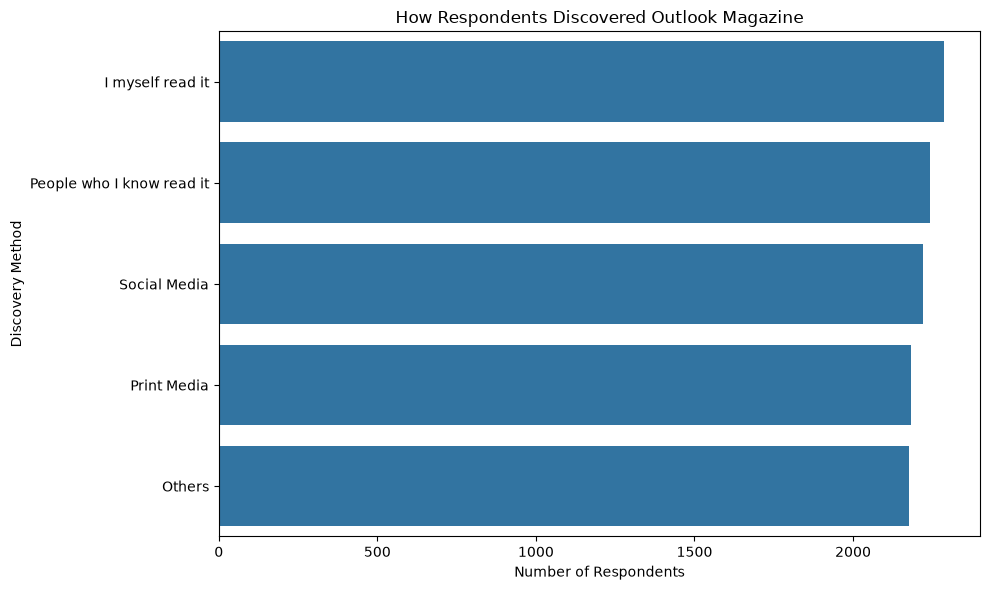

In [15]:
# =========================================================
# DISCOVERY CHANNEL VISUALIZATION
# =========================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="brand_discovery_method",
    order=df["brand_discovery_method"].value_counts().index
)

plt.title("How Respondents Discovered Outlook Magazine")
plt.xlabel("Number of Respondents")
plt.ylabel("Discovery Method")

plt.tight_layout()
plt.show()

In [16]:
# =========================================================
# DIGITAL PURCHASE FREQUENCY
# =========================================================

purchase_frequency = (
    df["digital_purchase_frequency"]
    .value_counts()
    .rename_axis("purchase_frequency")
    .reset_index(name="count")
)

purchase_frequency["percentage"] = (
    purchase_frequency["count"]
    / len(df)
    * 100
).round(2)

purchase_frequency

,purchase_frequency,count,percentage
0,Frequently,2234,20.11
1,Regularly,2233,20.10
2,Weekly,2220,19.98
3,Yearly,2219,19.97
4,Monthly,2203,19.83


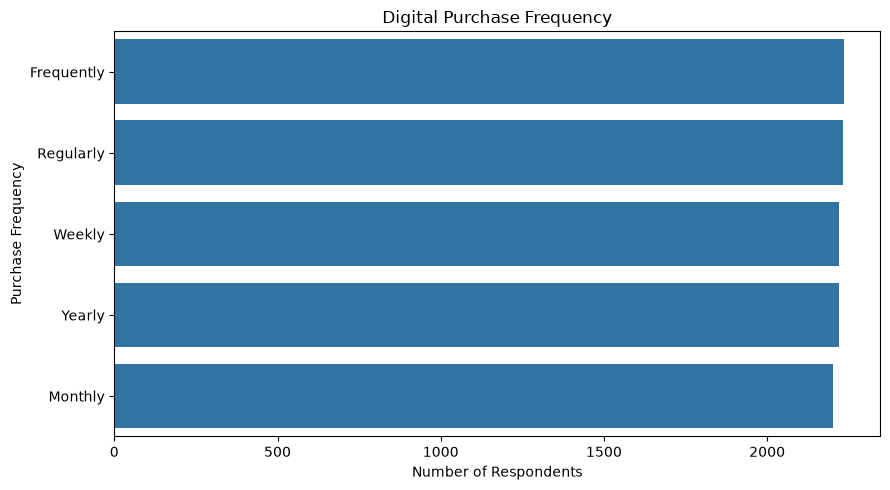

In [17]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    y="digital_purchase_frequency",
    order=df["digital_purchase_frequency"].value_counts().index
)

plt.title("Digital Purchase Frequency")
plt.xlabel("Number of Respondents")
plt.ylabel("Purchase Frequency")

plt.tight_layout()
plt.show()

In [18]:
# =========================================================
# DIGITAL MONTHLY SPEND
# =========================================================

spend_summary = (
    df["digital_monthly_spend"]
    .value_counts()
    .rename_axis("monthly_spend")
    .reset_index(name="count")
)

spend_summary["percentage"] = (
    spend_summary["count"]
    / len(df)
    * 100
).round(2)

spend_summary

,monthly_spend,count,percentage
0,500-1000,2304,20.74
1,1000-2000,2239,20.15
2,Above 5000,2208,19.88
3,2000-5000,2182,19.64
4,Below 500,2176,19.59


In [19]:
# =========================================================
# REPURCHASE INTENT
# =========================================================

repurchase_summary = (
    df["repurchase_intent"]
    .value_counts()
    .rename_axis("repurchase_intent")
    .reset_index(name="count")
)

repurchase_summary["percentage"] = (
    repurchase_summary["count"]
    / len(df)
    * 100
).round(2)

repurchase_summary

,repurchase_intent,count,percentage
0,Yes,3773,33.96
1,Will think of it,3668,33.02
2,No,3668,33.02


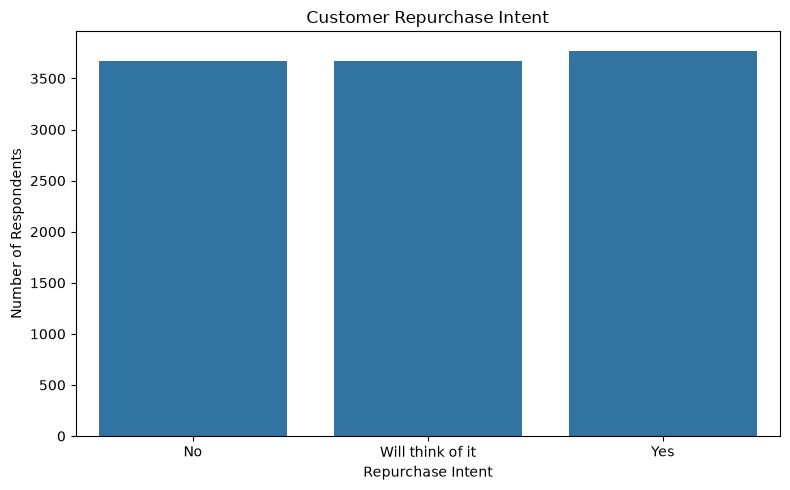

In [20]:
plt.figure(figsize=(8, 5))

order = [
    "No",
    "Will think of it",
    "Yes"
]

sns.countplot(
    data=df,
    x="repurchase_intent",
    order=order
)

plt.title("Customer Repurchase Intent")
plt.xlabel("Repurchase Intent")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.show()

In [21]:
# =========================================================
# RECOMMENDATION DISTRIBUTION
# =========================================================

recommendation_summary = (
    df["recommendation"]
    .value_counts()
    .sort_index()
    .rename_axis("recommendation_score")
    .reset_index(name="count")
)

recommendation_summary["percentage"] = (
    recommendation_summary["count"]
    / len(df)
    * 100
).round(2)

recommendation_summary

,recommendation_score,count,percentage
0,1,2265,20.39
1,2,2277,20.50
2,3,2157,19.42
3,4,2189,19.70
4,5,2221,19.99


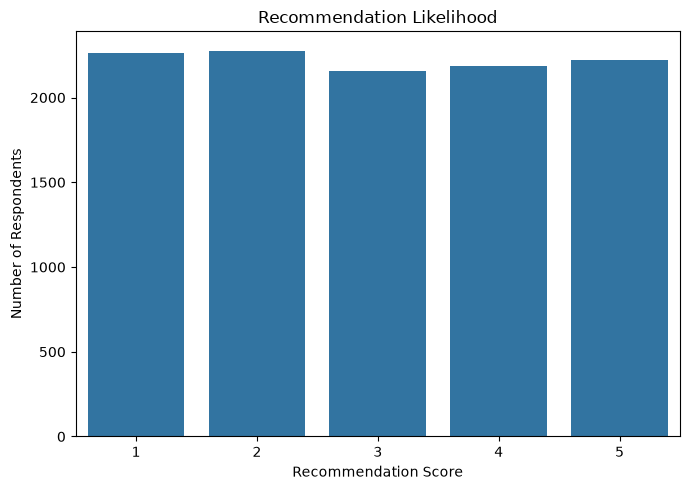

In [22]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="recommendation",
    order=[1, 2, 3, 4, 5]
)

plt.title("Recommendation Likelihood")
plt.xlabel("Recommendation Score")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.show()

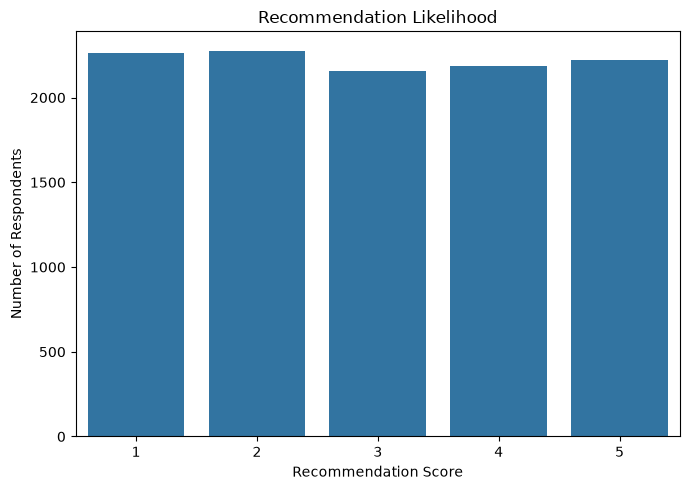

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="recommendation",
    order=[1, 2, 3, 4, 5]
)

plt.title("Recommendation Likelihood")
plt.xlabel("Recommendation Score")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.show()

In [24]:
# =========================================================
# CUSTOMER EXPERIENCE RANKING
# =========================================================

experience_columns = [
    "service_rating",
    "content_rating",
    "price_rating",
    "delivery_rating",
    "previous_experience_rating",
    "customer_support_rating"
]

experience_ranking = (
    df[experience_columns]
    .mean()
    .sort_values(ascending=False)
    .to_frame("average_rating")
)

experience_ranking["average_rating"] = (
    experience_ranking["average_rating"]
    .round(3)
)

experience_ranking

,average_rating
content_rating,3.018
previous_experience_rating,3.017
customer_support_rating,3.011
price_rating,3.008
service_rating,3.002
delivery_rating,3.001


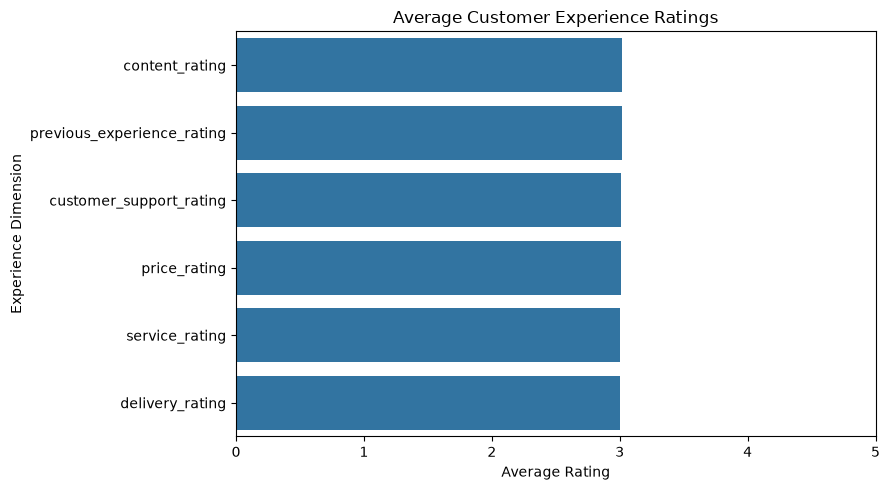

In [25]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=experience_ranking["average_rating"],
    y=experience_ranking.index
)

plt.title("Average Customer Experience Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Experience Dimension")

plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [26]:
# =========================================================
# SERVICE RATING BY REPURCHASE INTENT
# =========================================================

service_repurchase = (
    df.groupby("repurchase_intent")[
        "service_rating"
    ]
    .agg(["count", "mean", "median", "std"])
)

service_repurchase

,count,mean,median,std
repurchase_intent,,,,
No,3668,3.026990,3.0,1.432827
Will think of it,3668,3.017448,3.0,1.436492
Yes,3773,2.961304,3.0,1.418551


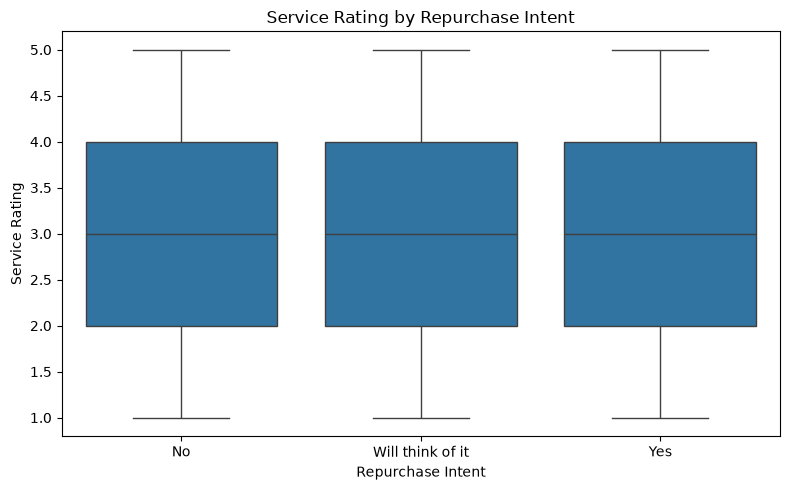

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="repurchase_intent",
    y="service_rating",
    order=[
        "No",
        "Will think of it",
        "Yes"
    ]
)

plt.title(
    "Service Rating by Repurchase Intent"
)

plt.xlabel("Repurchase Intent")
plt.ylabel("Service Rating")

plt.tight_layout()
plt.show()

In [28]:
# =========================================================
# AWARENESS × DISCOVERY METHOD
# =========================================================

awareness_discovery = pd.crosstab(
    df["brand_discovery_method"],
    df["outlook_awareness_1"],
    normalize="index"
) * 100

awareness_discovery = awareness_discovery.round(2)

awareness_discovery

outlook_awareness_1,No,Yes
brand_discovery_method,,
I myself read it,49.04,50.96
Others,51.52,48.48
People who I know read it,52.30,47.70
Print Media,50.05,49.95
Social Media,50.23,49.77


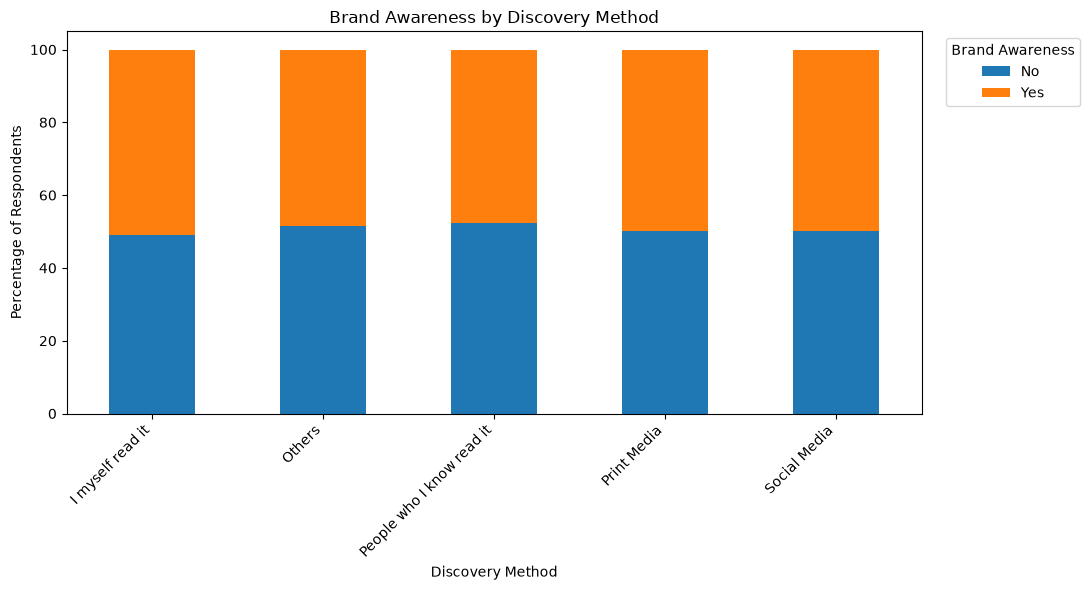

In [29]:
# =========================================================
# AWARENESS × DISCOVERY VISUALIZATION
# =========================================================

awareness_discovery.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title(
    "Brand Awareness by Discovery Method"
)

plt.xlabel("Discovery Method")
plt.ylabel("Percentage of Respondents")

plt.legend(
    title="Brand Awareness",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [30]:
# =========================================================
# AWARENESS × DIGITAL AD PLATFORM
# =========================================================

awareness_platform = pd.crosstab(
    df["digital_ad_platform"],
    df["outlook_awareness_1"],
    normalize="index"
) * 100

awareness_platform.round(2)

outlook_awareness_1,No,Yes
digital_ad_platform,,
Bing,51.80,48.20
Facebook,49.01,50.99
Google,48.61,51.39
Instagram,51.99,48.01
LinkedIn,50.68,49.32
Others,52.52,47.48
Pinterest,52.71,47.29
Reddit,49.53,50.47
Spotify,48.85,51.15


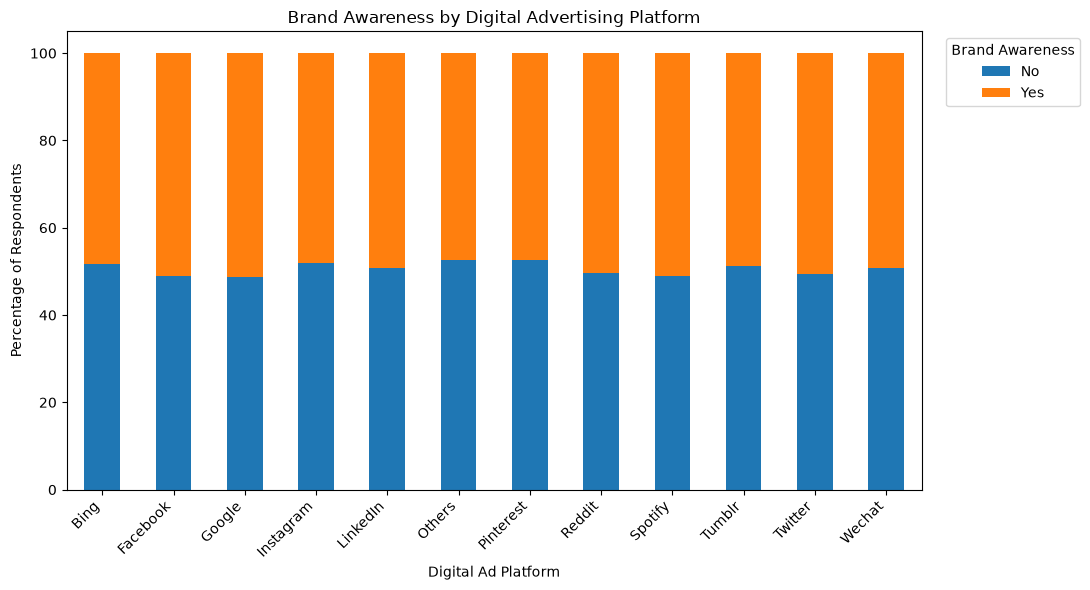

In [31]:
awareness_platform.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title(
    "Brand Awareness by Digital Advertising Platform"
)

plt.xlabel("Digital Ad Platform")
plt.ylabel("Percentage of Respondents")

plt.legend(
    title="Brand Awareness",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [32]:
# =========================================================
# AWARENESS × CAMPAIGN FREQUENCY
# =========================================================

awareness_campaign = pd.crosstab(
    df["digital_campaign_frequency"],
    df["outlook_awareness_1"],
    normalize="index"
) * 100

awareness_campaign.round(2)

outlook_awareness_1,No,Yes
digital_campaign_frequency,,
1-5 campaigns per month,51.09,48.91
11-20 campaigns per month,51.10,48.90
20+ campaigns per month,50.14,49.86
6-10 campaigns per month,50.13,49.87


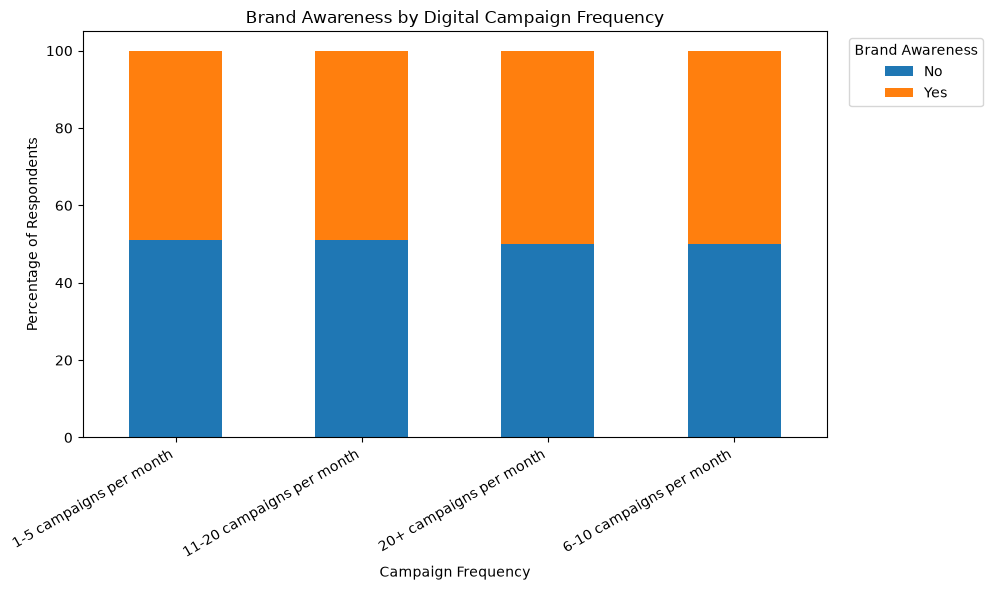

In [33]:
awareness_campaign.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title(
    "Brand Awareness by Digital Campaign Frequency"
)

plt.xlabel("Campaign Frequency")
plt.ylabel("Percentage of Respondents")

plt.legend(
    title="Brand Awareness",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [34]:
# =========================================================
# AWARENESS × DIGITAL PURCHASE FREQUENCY
# =========================================================

awareness_purchase = pd.crosstab(
    df["digital_purchase_frequency"],
    df["outlook_awareness_1"],
    normalize="index"
) * 100

awareness_purchase.round(2)

outlook_awareness_1,No,Yes
digital_purchase_frequency,,
Frequently,52.15,47.85
Monthly,50.34,49.66
Regularly,50.16,49.84
Weekly,48.42,51.58
Yearly,52.01,47.99


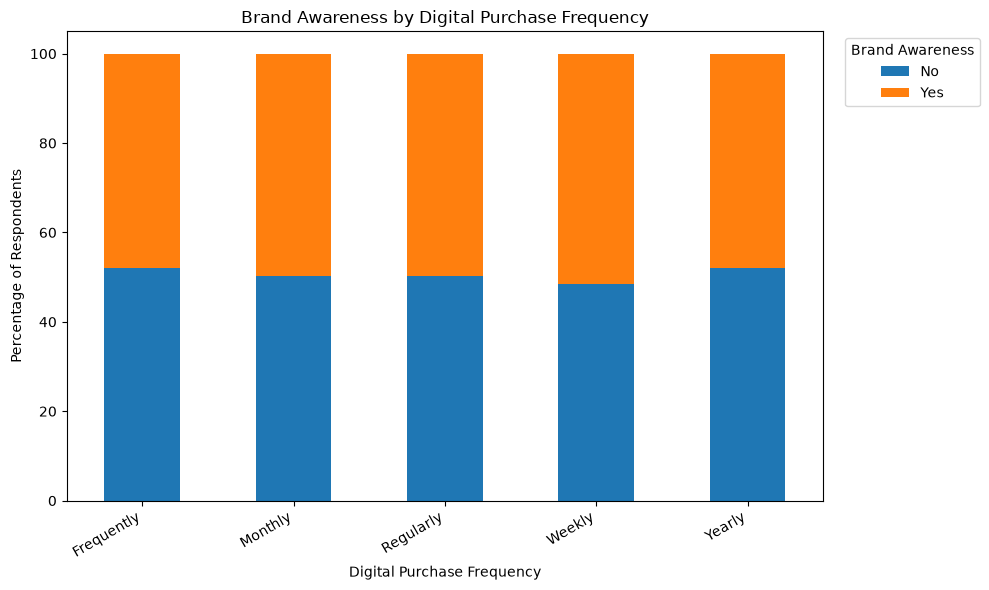

In [35]:
awareness_purchase.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title(
    "Brand Awareness by Digital Purchase Frequency"
)

plt.xlabel("Digital Purchase Frequency")
plt.ylabel("Percentage of Respondents")

plt.legend(
    title="Brand Awareness",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [36]:
# =========================================================
# AWARENESS × DIGITAL SPEND
# =========================================================

awareness_spend = pd.crosstab(
    df["digital_monthly_spend"],
    df["outlook_awareness_1"],
    normalize="index"
) * 100

awareness_spend.round(2)

outlook_awareness_1,No,Yes
digital_monthly_spend,,
1000-2000,49.13,50.87
2000-5000,50.18,49.82
500-1000,51.00,49.00
Above 5000,51.00,49.00
Below 500,51.79,48.21


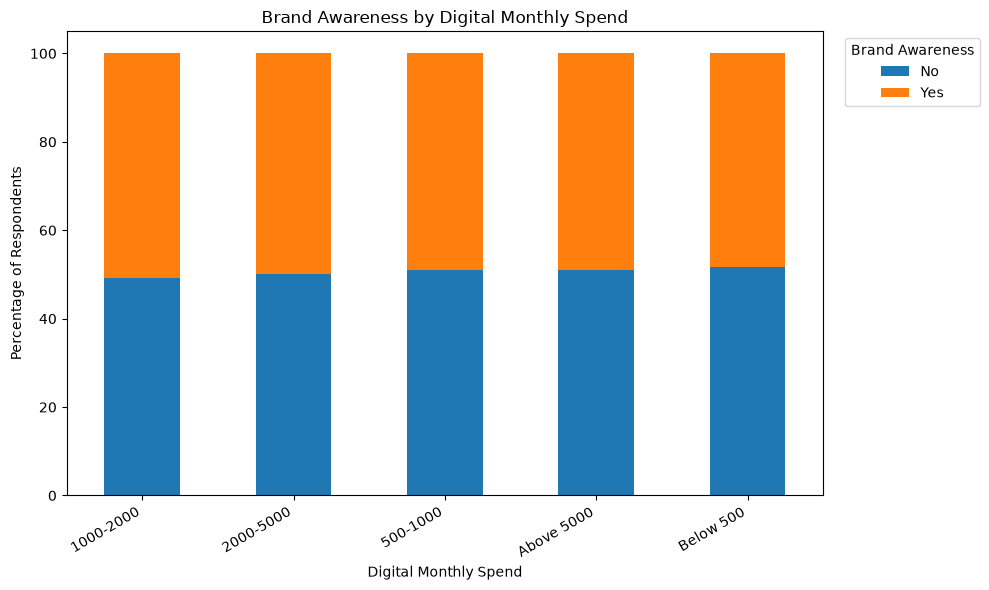

In [37]:
awareness_spend.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title(
    "Brand Awareness by Digital Monthly Spend"
)

plt.xlabel("Digital Monthly Spend")
plt.ylabel("Percentage of Respondents")

plt.legend(
    title="Brand Awareness",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [38]:
# =========================================================
# REPURCHASE × SERVICE
# =========================================================

repurchase_service = (
    df.groupby("repurchase_intent")[
        "service_rating"
    ]
    .agg([
        "count",
        "mean",
        "median",
        "std"
    ])
    .round(3)
)

repurchase_service

,count,mean,median,std
repurchase_intent,,,,
No,3668,3.027,3.0,1.433
Will think of it,3668,3.017,3.0,1.436
Yes,3773,2.961,3.0,1.419


In [39]:
# =========================================================
# EXPERIENCE × REPURCHASE
# =========================================================

experience_columns = [
    "service_rating",
    "content_rating",
    "price_rating",
    "delivery_rating",
    "previous_experience_rating",
    "customer_support_rating"
]

repurchase_experience = (
    df.groupby("repurchase_intent")[
        experience_columns
    ]
    .mean()
    .T
    .round(3)
)

repurchase_experience

repurchase_intent,No,Will think of it,Yes
service_rating,3.027,3.017,2.961
content_rating,3.005,3.018,3.029
price_rating,3.026,3.007,2.990
delivery_rating,2.974,3.006,3.021
previous_experience_rating,3.033,2.985,3.032
customer_support_rating,3.020,3.001,3.011


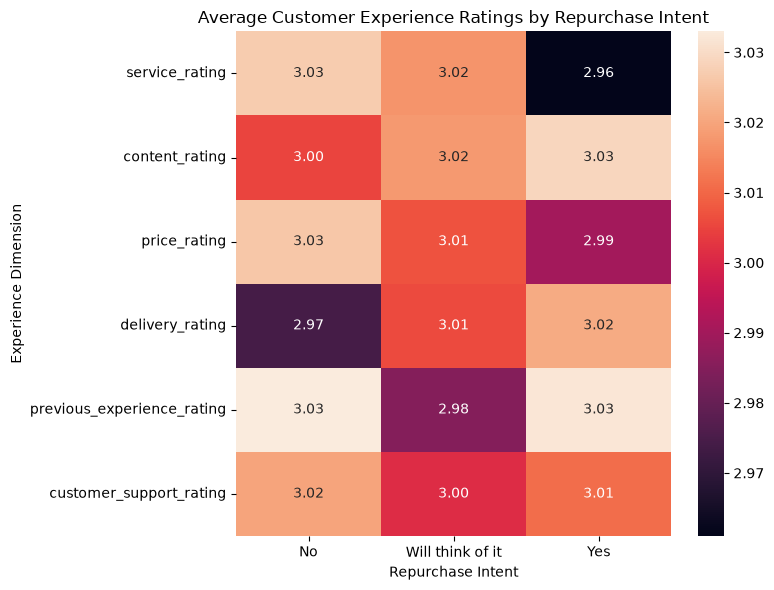

In [40]:
# =========================================================
# EXPERIENCE × REPURCHASE HEATMAP
# =========================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    repurchase_experience,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Average Customer Experience Ratings by Repurchase Intent"
)

plt.xlabel("Repurchase Intent")
plt.ylabel("Experience Dimension")

plt.tight_layout()
plt.show()

In [41]:
# =========================================================
# RECOMMENDATION × REPURCHASE
# =========================================================

recommendation_repurchase = (
    df.groupby("repurchase_intent")[
        "recommendation"
    ]
    .agg([
        "count",
        "mean",
        "median",
        "std"
    ])
    .round(3)
)

recommendation_repurchase

,count,mean,median,std
repurchase_intent,,,,
No,3668,2.981,3.0,1.429
Will think of it,3668,2.976,3.0,1.407
Yes,3773,2.995,3.0,1.425


In [42]:
# =========================================================
# RECOMMENDATION CATEGORY × REPURCHASE
# =========================================================

recommendation_repurchase_pct = pd.crosstab(
    df["recommendation_category"],
    df["repurchase_intent"],
    normalize="index"
) * 100

recommendation_repurchase_pct.round(2)

repurchase_intent,No,Will think of it,Yes
recommendation_category,,,
Detractor,32.98,33.25,33.77
Passive,31.99,33.61,34.40
Promoter,33.56,32.49,33.95


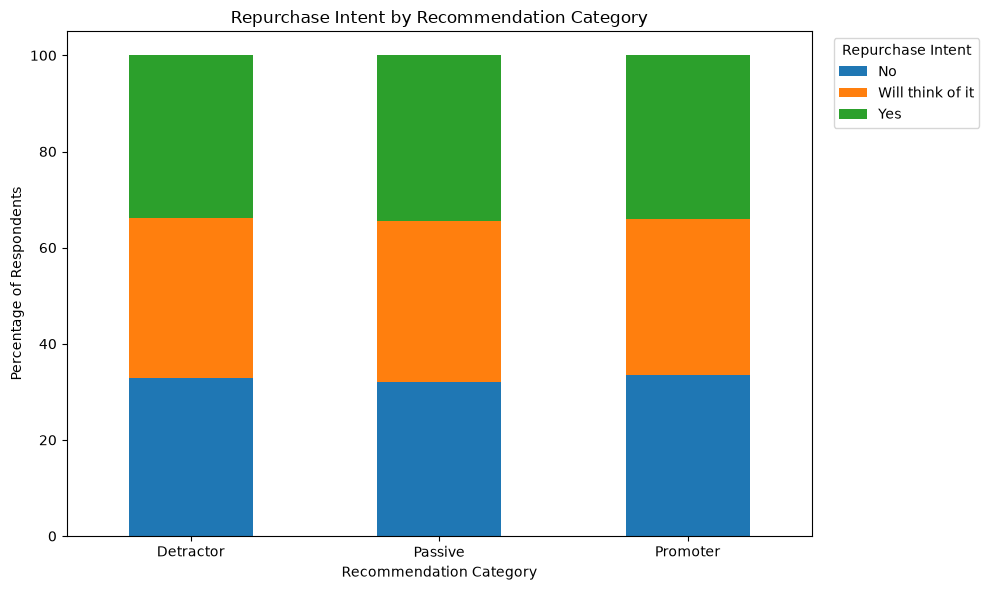

In [43]:
recommendation_repurchase_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title(
    "Repurchase Intent by Recommendation Category"
)

plt.xlabel("Recommendation Category")
plt.ylabel("Percentage of Respondents")

plt.legend(
    title="Repurchase Intent",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [44]:
# =========================================================
# SPEARMAN CORRELATION
# =========================================================

correlation_columns = [
    "recommendation",
    "service_rating",
    "content_rating",
    "price_rating",
    "delivery_rating",
    "previous_experience_rating",
    "customer_support_rating",
    "outlook_familiarity",
    "brand_solution_rating",
    "overall_magazine_rating",
    "overall_experience_rating"
]

spearman_matrix = df[
    correlation_columns
].corr(
    method="spearman"
).round(3)

spearman_matrix

,recommendation,service_rating,content_rating,price_rating,delivery_rating,previous_experience_rating,customer_support_rating,outlook_familiarity,brand_solution_rating,overall_magazine_rating,overall_experience_rating
recommendation,1.000,-0.002,0.014,-0.006,0.008,-0.003,-0.002,-0.009,0.003,0.005,-0.001
service_rating,-0.002,1.000,0.003,-0.012,0.003,-0.000,0.016,-0.003,0.009,-0.000,-0.009
content_rating,0.014,0.003,1.000,-0.010,-0.001,0.002,0.004,0.000,-0.008,0.012,-0.005
price_rating,-0.006,-0.012,-0.010,1.000,0.007,-0.013,0.006,0.005,-0.010,0.005,-0.014
delivery_rating,0.008,0.003,-0.001,0.007,1.000,0.015,0.000,0.018,0.005,0.019,-0.003
previous_experience_rating,-0.003,-0.000,0.002,-0.013,0.015,1.000,0.005,-0.006,-0.001,0.011,0.004
customer_support_rating,-0.002,0.016,0.004,0.006,0.000,0.005,1.000,0.009,-0.007,0.012,0.004
outlook_familiarity,-0.009,-0.003,0.000,0.005,0.018,-0.006,0.009,1.000,0.011,-0.007,0.014
brand_solution_rating,0.003,0.009,-0.008,-0.010,0.005,-0.001,-0.007,0.011,1.000,0.016,0.008
overall_magazine_rating,0.005,-0.000,0.012,0.005,0.019,0.011,0.012,-0.007,0.016,1.000,-0.017


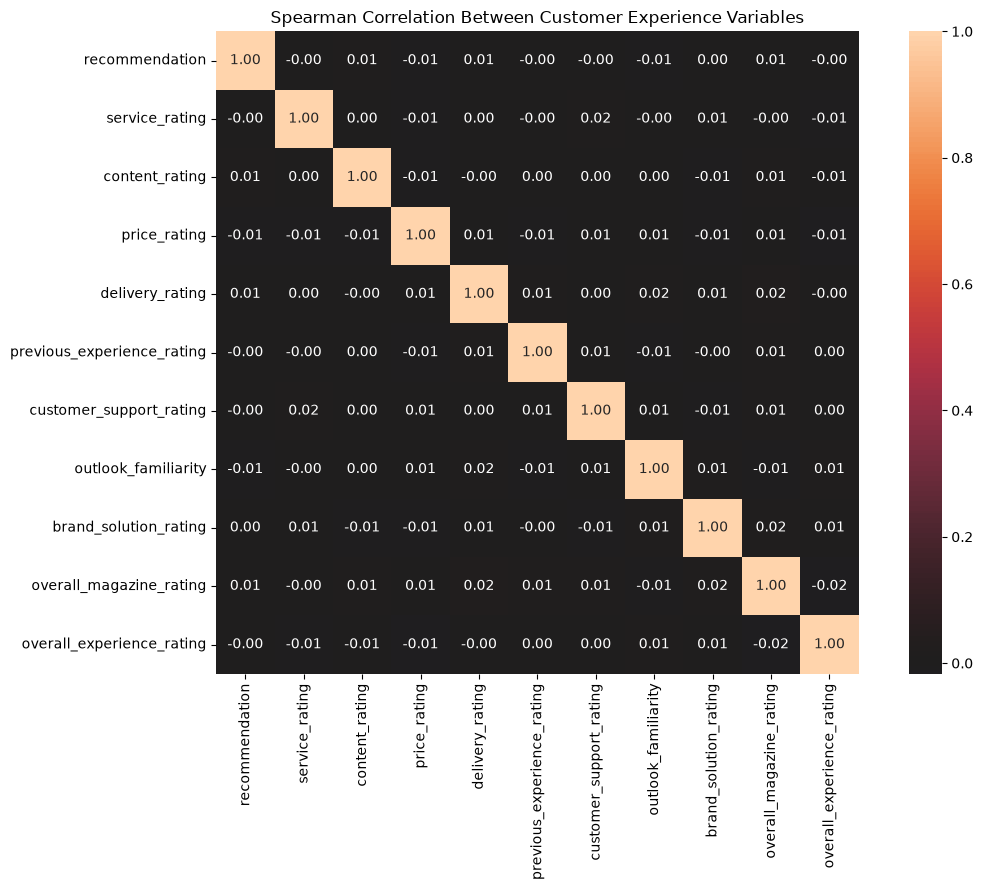

In [45]:
# =========================================================
# SPEARMAN CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(12, 9))

sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    square=True
)

plt.title(
    "Spearman Correlation Between Customer Experience Variables"
)

plt.tight_layout()
plt.show()

In [46]:
# =========================================================
# STRONGEST SPEARMAN RELATIONSHIPS
# =========================================================

correlation_pairs = []

for i in range(len(correlation_columns)):

    for j in range(i + 1, len(correlation_columns)):

        col1 = correlation_columns[i]
        col2 = correlation_columns[j]

        correlation = spearman_matrix.loc[
            col1,
            col2
        ]

        correlation_pairs.append({
            "variable_1": col1,
            "variable_2": col2,
            "spearman_rho": correlation
        })


strongest_relationships = (
    pd.DataFrame(correlation_pairs)
    .assign(
        absolute_rho=lambda x:
        x["spearman_rho"].abs()
    )
    .sort_values(
        "absolute_rho",
        ascending=False
    )
    .head(15)
    .drop(columns="absolute_rho")
)

strongest_relationships

,variable_1,variable_2,spearman_rho
38,delivery_rating,overall_magazine_rating,0.019
36,delivery_rating,outlook_familiarity,0.018
54,overall_magazine_rating,overall_experience_rating,-0.017
52,brand_solution_rating,overall_magazine_rating,0.016
14,service_rating,customer_support_rating,0.016
34,delivery_rating,previous_experience_rating,0.015
1,recommendation,content_rating,0.014
51,outlook_familiarity,overall_experience_rating,0.014
33,price_rating,overall_experience_rating,-0.014
28,price_rating,previous_experience_rating,-0.013
